In [58]:
#Import Libraries 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier

In [59]:
# LOAD DATASET
df = pd.read_csv('/Users/diyapatel/Desktop/DTSC 3601/Crime_Data_from_2020_to_Present .csv')

In [60]:
TARGET_COL = "Crm Cd Desc"  
violent_keywords = ["ASSAULT", "HOMICIDE", "KIDNAPPING"]
df = df[df[TARGET_COL].astype(str).str.contains("|".join(violent_keywords), case=False, na=False)]

print("Filtered dataset shape:", df.shape)
print("Unique crime types:", sorted(df[TARGET_COL].dropna().unique().tolist()))

Filtered dataset shape: (199840, 28)
Unique crime types: ['ASSAULT WITH DEADLY WEAPON ON POLICE OFFICER', 'ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT', 'BATTERY - SIMPLE ASSAULT', 'CHILD ABUSE (PHYSICAL) - AGGRAVATED ASSAULT', 'CHILD ABUSE (PHYSICAL) - SIMPLE ASSAULT', 'CRIMINAL HOMICIDE', 'INTIMATE PARTNER - AGGRAVATED ASSAULT', 'INTIMATE PARTNER - SIMPLE ASSAULT', 'KIDNAPPING', 'KIDNAPPING - GRAND ATTEMPT', 'OTHER ASSAULT']


In [61]:
d = df.copy()

In [62]:
d["Vict Age"] = pd.to_numeric(d.get("Vict Age"), errors="coerce")
d["Vict Sex"] = d.get("Vict Sex", "Unknown").astype("string").fillna("Unknown")
d["Vict Descent"] = d.get("Vict Descent", "Unknown").astype("string").fillna("Unknown")

# Helpful age bucket
d["Vict Age Group"] = pd.cut(
    d["Vict Age"], bins=[-1, 17, 30, 50, 120],
    labels=["<18", "18-30", "31-50", "51+"], include_lowest=True
).astype("string")

# Neighborhood/time features (gracefully handle missing column variants)
if "DATE OCC" in d.columns:
    d["DATE OCC"] = pd.to_datetime(d["DATE OCC"], errors="coerce")
    d["Year"] = d["DATE OCC"].dt.year
    d["Month"] = d["DATE OCC"].dt.month
    d["DayOfWeek"] = d["DATE OCC"].dt.dayofweek
else:
    d["Year"] = np.nan
    d["Month"] = np.nan
    d["DayOfWeek"] = np.nan

/var/folders/z8/tx5kspls16b14cv40xhpxrv00000gn/T/ipykernel_3539/1441698032.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  d["DATE OCC"] = pd.to_datetime(d["DATE OCC"], errors="coerce")


In [63]:
# Common LAPD neighborhood columns
area_col = "AREA NAME" if "AREA NAME" in d.columns else ("AREA " if "AREA " in d.columns else ("AREA" if "AREA" in d.columns else None))
rd_col = "RD" if "RD" in d.columns else ("Rpt Dist No" if "Rpt Dist No" in d.columns else None)

if area_col is None:
    d["AREA NAME"] = "Unknown"
else:
    d["AREA NAME"] = d[area_col].astype("string").fillna("Unknown")

if rd_col is None:
    d["RD"] = "Unknown"
else:
    d["RD"] = d[rd_col].astype("string").fillna("Unknown")


In [64]:
# Keep rows with target present
d = d.dropna(subset=[TARGET_COL]).reset_index(drop=True)

In [65]:

#  Define feature sets
victim_only_features = [c for c in ["Vict Age", "Vict Sex", "Vict Descent", "Vict Age Group"] if c in d.columns]
neighborhood_features = [c for c in ["AREA NAME", "RD", "Year", "Month", "DayOfWeek"] if c in d.columns]
victim_plus_neigh_features = victim_only_features + neighborhood_features

# y = target
y = d[TARGET_COL].astype("string")



In [66]:
#  Train/test split (same for both models)
X_train, X_test, y_train, y_test = train_test_split(
    d, y, test_size=0.3, random_state=42, stratify=y
)

In [67]:
#  Pipelines (encode inside the pipeline to avoid leakage)
def make_ohe():
# compatibility across sklearn versions
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

def make_pipeline(feature_list):
    # infer numeric vs categorical from TRAIN dtypes
    num_feats = [c for c in feature_list if pd.api.types.is_numeric_dtype(X_train[c])]
    cat_feats = [c for c in feature_list if c not in num_feats]

    pre = ColumnTransformer(
        transformers=[
            ("num", "passthrough", num_feats),
            ("cat", make_ohe(), cat_feats),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )
    clf = DecisionTreeClassifier(max_depth=6, random_state=42)
    return Pipeline([("pre", pre), ("clf", clf)])

pipe_A = make_pipeline(victim_only_features)            # Model A: Victim-only
pipe_B = make_pipeline(victim_plus_neigh_features)      # Model B: Victim + Neighborhood


In [68]:
# Fit
pipe_A.fit(X_train[victim_only_features], y_train)
pipe_B.fit(X_train[victim_plus_neigh_features], y_train)

Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['Vict Age', 'Year', 'Month',
                                                   'DayOfWeek']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['Vict Sex', 'Vict Descent',
                                                   'Vict Age Group',
                                                   'AREA NAME', 'RD'])],
                                   verbose_feature_names_out=False)),
                ('clf', DecisionTreeClassifier(max_depth=6, random_state=42))])

In [69]:
# 8) Predict & evaluate
def evaluate(pipe, X, y_true, label):
    y_pred = pipe.predict(X)
    acc = accuracy_score(y_true, y_pred)
    f1m = f1_score(y_true, y_pred, average="macro")
    report = classification_report(y_true, y_pred, zero_division=0)
    cm = confusion_matrix(y_true, y_pred, labels=sorted(y_true.unique()))
    return y_pred, acc, f1m, report, cm

y_pred_A, acc_A, f1_A, rpt_A, cm_A = evaluate(pipe_A, X_test[victim_only_features], y_test, "A")
y_pred_B, acc_B, f1_B, rpt_B, cm_B = evaluate(pipe_B, X_test[victim_plus_neigh_features], y_test, "B")

In [70]:
#  Summary table
summary = pd.DataFrame([
    {"Model": "A) Victim-only", "Features": len(victim_only_features), "Accuracy": acc_A, "F1 (macro)": f1_A},
    {"Model": "B) Victim + Neighborhood", "Features": len(victim_plus_neigh_features), "Accuracy": acc_B, "F1 (macro)": f1_B},
]).sort_values("Accuracy", ascending=False).reset_index(drop=True)

print("=== Model Comparison (DecisionTree max_depth=6) ===")
print(summary.to_string(index=False))

print("\n Classification Report: Model A (Victim-only) ")
print(rpt_A)
print("\n Classification Report: Model B (Victim + Neighborhood) ")
print(rpt_B)


=== Model Comparison (DecisionTree max_depth=6) ===
                   Model  Features  Accuracy  F1 (macro)
B) Victim + Neighborhood         9  0.457216    0.178100
          A) Victim-only         4  0.453796    0.174409

 Classification Report: Model A (Victim-only) 
                                                precision    recall  f1-score   support

  ASSAULT WITH DEADLY WEAPON ON POLICE OFFICER       0.00      0.00      0.00       323
ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT       0.44      0.46      0.45     16057
                      BATTERY - SIMPLE ASSAULT       0.49      0.47      0.48     22452
   CHILD ABUSE (PHYSICAL) - AGGRAVATED ASSAULT       0.00      0.00      0.00       184
       CHILD ABUSE (PHYSICAL) - SIMPLE ASSAULT       0.55      0.43      0.48      1067
                             CRIMINAL HOMICIDE       0.00      0.00      0.00       470
         INTIMATE PARTNER - AGGRAVATED ASSAULT       0.00      0.00      0.00      3797
             INTIMATE PA

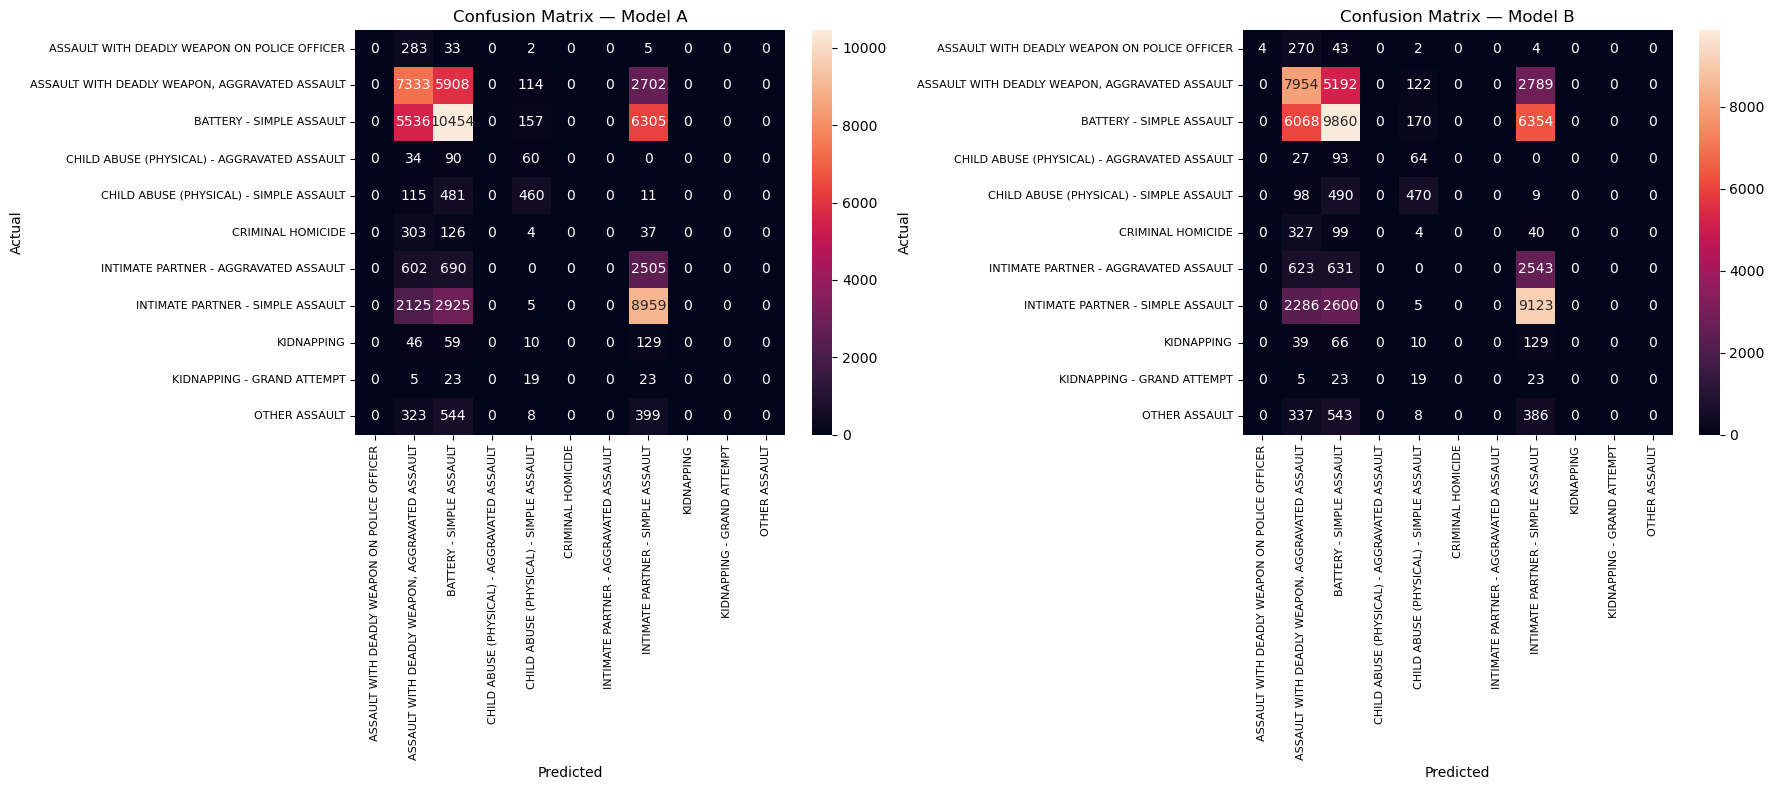

In [71]:
# 10) Confusion matrices (side-by-side)
labels_sorted = sorted(y_test.unique())
fig, axes = plt.subplots(1, 2, figsize=(18, 8))  # made figure a bit larger

sns.heatmap(cm_A, annot=True, fmt="d", ax=axes[0],
            xticklabels=labels_sorted, yticklabels=labels_sorted)
axes[0].set_title("Confusion Matrix — Model A")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")
axes[0].tick_params(axis="x", rotation=90, labelsize=8)  #  rotate & shrink
axes[0].tick_params(axis="y", rotation=0, labelsize=8)

sns.heatmap(cm_B, annot=True, fmt="d", ax=axes[1],
            xticklabels=labels_sorted, yticklabels=labels_sorted)
axes[1].set_title("Confusion Matrix — Model B")
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Actual")
axes[1].tick_params(axis="x", rotation=90, labelsize=8)  #  rotate & shrink
axes[1].tick_params(axis="y", rotation=0, labelsize=8)

plt.tight_layout()
plt.show()
